# Week 4
Direct linear transform (DLT), linear algorithm for camera calibration and
checkerboard calibration, and bundle adjustment from Zhang (2000).

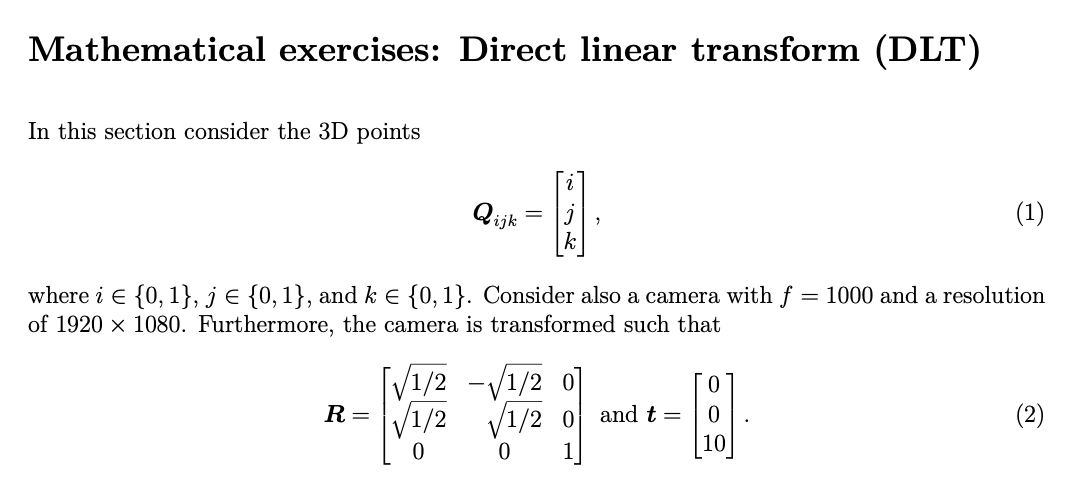

In [2]:
import numpy as np

f = 1000 
res = np.array([1920, 1080])

R = np.array([[np.sqrt(1/2), -np.sqrt(1/2), 0],
              [np.sqrt(1/2), np.sqrt(1/2), 0],
              [0, 0, 1]])

t = np.array([[0], [0], [10]])

K = np.array([[f, 0, res[0]/2],
              [0, f, res[1]/2],
              [0, 0, 1]])
      
# 3. Generate all 8 3D points (Q_ijk) using a clean list comprehension
Q_list = [np.array([[i], [j], [k]]) for i in [0, 1] for j in [0, 1] for k in [0, 1]]

print("--- Camera Intrinsic Matrix K ---")
print(K)
print("\n--- Total 3D Points Generated ---")
print(f"Generated {len(Q_list)} corner points successfully.")
print(f"Example point Q_011:\n{Q_list[3]}")

--- Camera Intrinsic Matrix K ---
[[1000.    0.  960.]
 [   0. 1000.  540.]
 [   0.    0.    1.]]

--- Total 3D Points Generated ---
Generated 8 corner points successfully.
Example point Q_011:
[[0]
 [1]
 [1]]


## 4.1 

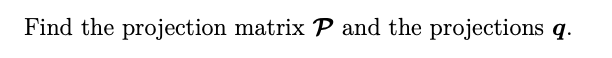

In [12]:
np.set_printoptions(precision=4, suppress=True)

P = K @ np.hstack((R, t))
print("\n--- Full Projection Matrix P ---")
print(P)

# Create a list to store our final 2D pixel coordinates
pixel_points = []

# Loop through each of the 8 cube points generated in your previous step
for Q_cube in Q_list:
    # 1. Convert the 3D point into a 4x1 homogeneous vector [X, Y, Z, 1]^T
    Q_homo = np.vstack((Q_cube, [1.0]))
    
    # 2. Project using your combined matrix P (yields a 3x1 homogeneous image vector)
    p_homo = P @ Q_homo
    
    # 3. Perform the division step to drop back to 2D pixel space (x_pixel, y_pixel)
    x_pixel = p_homo[0, 0] / p_homo[2, 0]
    y_pixel = p_homo[1, 0] / p_homo[2, 0]
    
    # Pack into a standard coordinate array
    pixel_points.append(np.array([[x_pixel], [y_pixel]]))

print("--- 2D Projected Pixel Coordinates ---")
print(f"Total points projected: {len(pixel_points)}")
print(f"First projected corner position p_000:\n{pixel_points[0]}")
print(f"First projected corner position p_001:\n{pixel_points[1]}")
print(f"First projected corner position p_010:\n{pixel_points[2]}")
print(f"First projected corner position p_011:\n{pixel_points[3]}")
print(f"First projected corner position p_100:\n{pixel_points[4]}")
print(f"First projected corner position p_101:\n{pixel_points[5]}")
print(f"First projected corner position p_110:\n{pixel_points[6]}")
print(f"First projected corner position p_111:\n{pixel_points[7]}")



--- Full Projection Matrix P ---
[[ 707.1068 -707.1068  960.     9600.    ]
 [ 707.1068  707.1068  540.     5400.    ]
 [   0.        0.        1.       10.    ]]
--- 2D Projected Pixel Coordinates ---
Total points projected: 8
First projected corner position p_000:
[[960.]
 [540.]]
First projected corner position p_001:
[[960.]
 [540.]]
First projected corner position p_010:
[[889.2893]
 [610.7107]]
First projected corner position p_011:
[[895.7176]
 [604.2824]]
First projected corner position p_100:
[[1030.7107]
 [ 610.7107]]
First projected corner position p_101:
[[1024.2824]
 [ 604.2824]]
First projected corner position p_110:
[[960.    ]
 [681.4214]]
First projected corner position p_111:
[[960.    ]
 [668.5649]]


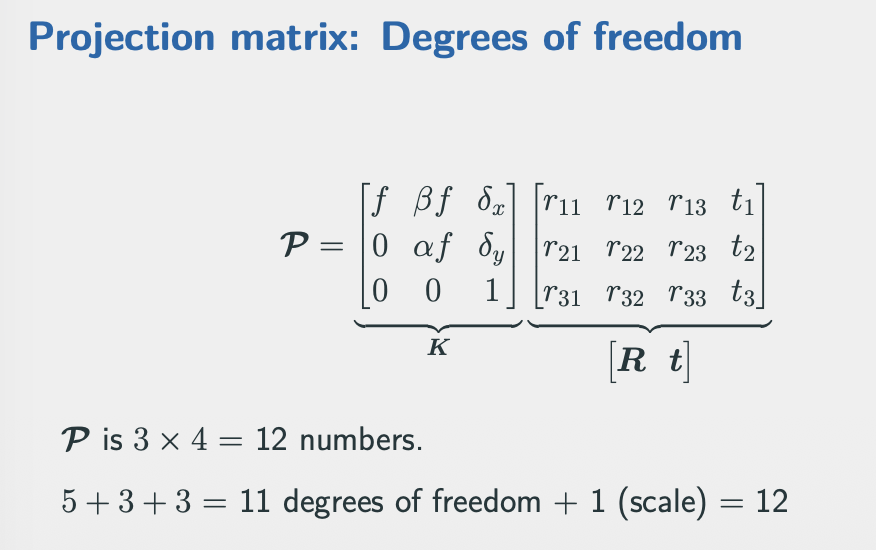

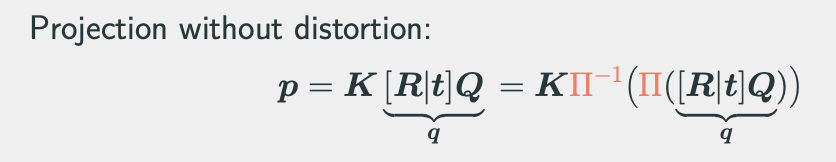

## 4.2

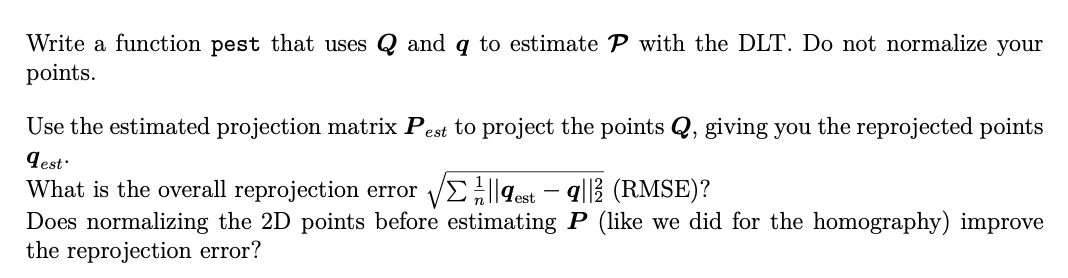

In [13]:
import numpy as np

def pest(Q, q):
    """
    Estimates the 3x4 camera projection matrix P using the Direct Linear Transform (DLT).
    
    Parameters:
    ---------
    Q : list of arrays or numpy array
        List of 3D world points. Each point should be a 3x1 column vector or 4x1 homogeneous vector.
    q : list of arrays or numpy array
        List of matching 2D pixel points. Each point should be a 2x1 or 3x1 vector.
    """
    num_points = len(Q)
    A = []
    
    for i in range(num_points):
        # 1. Ensure the 3D point is in homogeneous form [X, Y, Z, 1] (flat row)
        Q_homo = Q[i].flatten()
        if len(Q_homo) == 3:
            Q_homo = np.append(Q_homo, 1.0)
            
        # 2. Extract the matching inhomogeneous 2D pixel coordinates (x, y)
        x, y = q[i][0, 0], q[i][1, 0]
        
        # 3. Construct the two linear rows for the design matrix A
        row1 = np.hstack(([0, 0, 0, 0],   -Q_homo,        y * Q_homo))
        row2 = np.hstack((Q_homo,        [0, 0, 0, 0],   -x * Q_homo))
        
        A.append(row1)
        A.append(row2)
        
    A = np.array(A)
    
    # 4. Solve the homogeneous system A * p = 0 using Singular Value Decomposition
    _, _, Vh = np.linalg.svd(A)
    
    # The solution is the last row of Vh (which corresponds to the smallest singular value)
    p_vector = Vh[-1]
    
    # 5. Reshape the flat 12-element vector back into a 3x4 projection matrix
    P_est = p_vector.reshape(3, 4)
    
    return P_est

In [14]:
# Force clean printing options
np.set_printoptions(suppress=True, precision=4)

# Run your DLT estimator function
P_est = pest(Q_list, pixel_points)

print("--- Estimated Projection Matrix P_est ---")
print(P_est)

--- Estimated Projection Matrix P_est ---
[[-0.0634  0.0634 -0.086  -0.8603]
 [-0.0634 -0.0634 -0.0484 -0.4839]
 [ 0.     -0.     -0.0001 -0.0009]]


In [15]:
print("\n--- Scale Normalized True Matrix P ---")
print(P / P[2, 3])

print("\n--- Scale Normalized Estimated Matrix P_est ---")
print(P_est / P_est[2, 3])


--- Scale Normalized True Matrix P ---
[[ 70.7107 -70.7107  96.     960.    ]
 [ 70.7107  70.7107  54.     540.    ]
 [  0.       0.       0.1      1.    ]]

--- Scale Normalized Estimated Matrix P_est ---
[[ 70.7107 -70.7107  96.     960.    ]
 [ 70.7107  70.7107  54.     540.    ]
 [ -0.       0.       0.1      1.    ]]


The projection matrix and the reprojections are identical to the original within machine precision.
The reprojection error on my system is approximately 10−11 without normalization and 10−14 with
normalization.